# Library Import

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import ace_tools_open as tools
from matplotlib import font_manager, rc
import platform
import requests
import pandas as pd
import time
import requests

if platform.system() == 'Windows':
    font_path = "c:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    rc('font', family=font_name)
elif platform.system() == 'Darwin':
    rc('font', family='AppleGothic')

plt.rcParams['axes.unicode_minus'] = False

KAKAO_API_KEY = "YOUR_API_KEY" # Need to replace with actual API key

# Metric 1) 혼합밀집도
* 본 데이터는 '화성산업단지관리사업소'에서 다운로드 받음.
* 발안일반산업단지, 동탄일반산업단지, 동탄도시첨단산업단지가 회사가 가장 많음.

In [2]:
company_df = pd.read_csv("../data/statistics/산업단지별_회사_데이터.csv", index_col = 0)
company_df

,회사수,면적,직원수
단지명,,,
화성발안일반산업단지,424,1825,8884
화성동탄일반산업단지,328,1974,14237
화성동탄도시첨단산업단지,251,149,3935
화성전곡해양일반산업단지,233,1617,4051
화성바이오밸리일반산업단지,227,1740,4787
화성마도일반산업단지,173,929,4029
화성송산테크노파크일반산업단지,99,529,1513
화성정남일반산업단지,95,569,2956
화성향남제약일반산업단지,48,648,4409


In [3]:
company_df['직원밀집도'] = company_df['직원수'] /  company_df['면적']
company_df['기업밀집도'] = company_df['회사수'] /  company_df['면적']

human_weight = 0.7
company_weight = 0.3

company_df["혼합밀집도"] = (company_df["직원밀집도"] * human_weight) + (company_df["기업밀집도"] * company_weight)
company_df

,회사수,면적,직원수,직원밀집도,기업밀집도,혼합밀집도
단지명,,,,,,
화성발안일반산업단지,424,1825,8884,4.867945,0.232329,3.477260
화성동탄일반산업단지,328,1974,14237,7.212259,0.166160,5.098430
화성동탄도시첨단산업단지,251,149,3935,26.409396,1.684564,18.991946
화성전곡해양일반산업단지,233,1617,4051,2.505257,0.144094,1.796908
화성바이오밸리일반산업단지,227,1740,4787,2.751149,0.130460,1.964943
화성마도일반산업단지,173,929,4029,4.336921,0.186222,3.091712
화성송산테크노파크일반산업단지,99,529,1513,2.860113,0.187146,2.058223
화성정남일반산업단지,95,569,2956,5.195079,0.166960,3.686643
화성향남제약일반산업단지,48,648,4409,6.804012,0.074074,4.785031


# Metric 2) 위험 업종 포함 비율

## 위험 업종 기준 선정
* 본 데이터는 '소방청'에서 다운로드 받았으며, "최초착화물별 재산 피해"를 보여줍니다.
* 위험 업종은 업종별 화재 발생 건수와 피해액을 기준으로 선정합니다.
* 이후, 각 산업단지별 위험 업종의 포함 비율에 따라 위험도를 산정합니다.

In [4]:
df = pd.read_csv("../data/statistics/최초착화물.csv")
df

,구분,Unnamed: 1,화재건수,사망,부상,인명피해 계,부동산피해(천원),동산피해(천원),재산피해(천원),재산피해/건당(천원)
0,합계,NaN,3177,43,210,253,79933592,137282377,217215969,68371
1,가구,소계,24,0,0,0,174016,143090,317106,13213
2,NaN,소파,2,0,0,0,56423,61688,118111,59056
3,NaN,옷장 책장 등,5,0,0,0,21530,30586,52116,10423
4,NaN,침대 매트리스,9,0,0,0,34999,17264,52263,5807
...,...,...,...,...,...,...,...,...,...,...
100,NaN,기타(합성수지),69,0,5,5,1580898,2886866,4467764,64750
101,미상,소계,120,1,24,25,17140748,33591742,50732490,422771
102,NaN,미상,120,1,24,25,17140748,33591742,50732490,422771
103,기타,소계,249,23,29,52,6544598,26148485,32693083,131298


### 피해액 계산
* 피해액: 인명피해 + 부동산피해 + 재산피해

In [5]:
damage_df = df[df["Unnamed: 1"] == "소계"].copy()
damage_df = damage_df[["구분", "화재건수", "인명피해 계", "부동산피해(천원)", "동산피해(천원)", "재산피해(천원)"]]
damage_df["Total Damage"] = damage_df["부동산피해(천원)"] + damage_df["동산피해(천원)"] + damage_df["재산피해(천원)"] + damage_df["인명피해 계"] * 1000000

damage_df_cleaned = damage_df[~damage_df["구분"].isin(["미상", "기타"])].copy()
damage_df_cleaned = damage_df_cleaned.sort_values(by="Total Damage", ascending=False)

#### Visualization

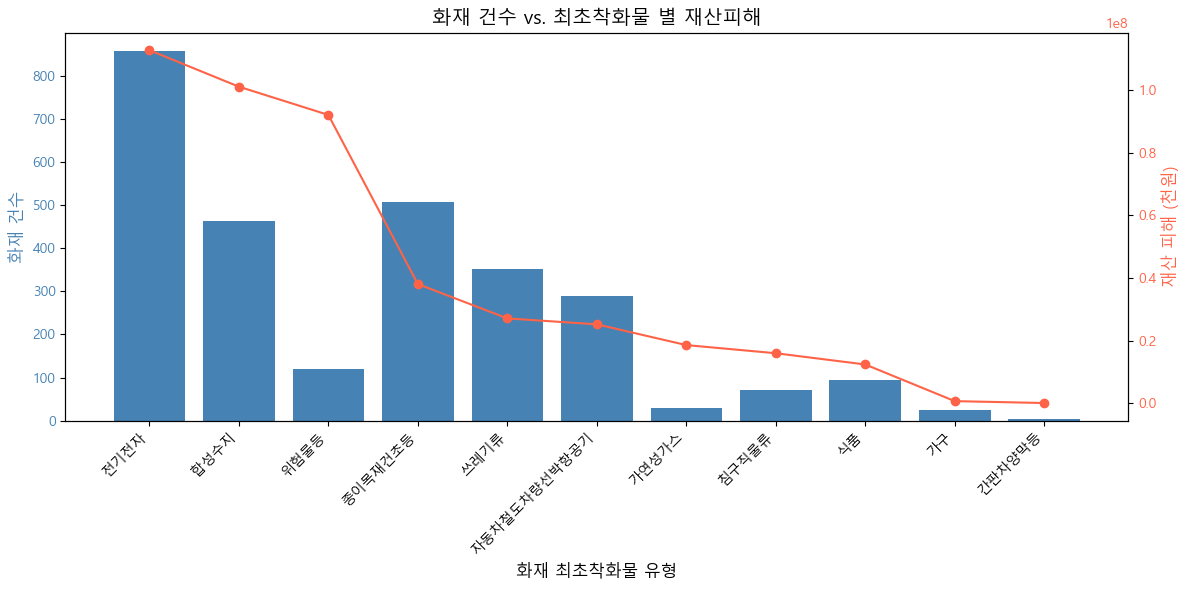

In [6]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# 막대: 화재 건수
ax1.bar(damage_df_cleaned["구분"], damage_df_cleaned["화재건수"], color="steelblue", label="Fire Cases")
ax1.set_ylabel("화재 건수", fontsize=12, color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# 꺾은선: 총 피해액
ax2 = ax1.twinx()
ax2.plot(damage_df_cleaned["구분"], damage_df_cleaned["Total Damage"], color="tomato", marker='o', label="Total Damage")
ax2.set_ylabel("재산 피해 (천원)", fontsize=12, color="tomato")
ax2.tick_params(axis="y", labelcolor="tomato")

# x축 회전
ax1.set_xlabel("화재 최초착화물 유형", fontsize=12)
for label in ax1.get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment('right')

plt.title("화재 건수 vs. 최초착화물 별 재산피해", fontsize=14)
fig.tight_layout()
plt.show()

# Insight: 전기 전자, 합성 수지에서 가장 많은 화재 건수와 피해액이 발생함.
#        : 추가적으로, 위험물의 경우 발생 건수는 적지만 피해액이 상당히 큼.
#        : 이에 따라, 위험 업종을 "전기전자", "합성수지", "위험물"로 정의하고, 이들 업종에 대한 특별한 화재 예방 대책이 필요함.

### 실제 데이터 연동
* 본 데이터는 '소방청'에서 다운로드 받은 데이터이며, 공개된 데이터를 실제 업종과 매핑하여 생성하였습니다.
* 공개된 데이터에 '합성수지' 업종은 포함되지 않아, "위험물", "전기전자"를 위험 업종으로 분류합니다.

In [7]:
company_type_df = pd.read_csv("../data/statistics/산업단지별_업종현황(소방청_연계).csv", index_col = 0)
company_type_df

,위험물등,전기전자,운송장비,목재종이출판,섬유의복,음식료,기타,합계
단지명,,,,,,,,
화성동탄일반산업단지,11,306,9,4,0,0,79,409
화성마도일반산업단지,22,152,23,0,0,0,74,271
화성발안일반산업단지,29,342,7,0,0,0,168,546
화성전곡해양일반산업단지,115,118,14,3,1,4,41,296
화성정남일반산업단지,26,76,0,0,0,4,10,116
화성향남제약일반산업단지,44,1,0,0,0,4,2,51
화성바이오밸리일반산업단지,86,131,20,7,0,4,57,305
화성주곡일반산업단지,5,13,4,3,1,1,7,34
화성화남일반산업단지,0,41,0,0,0,0,1,42


#### Visualization

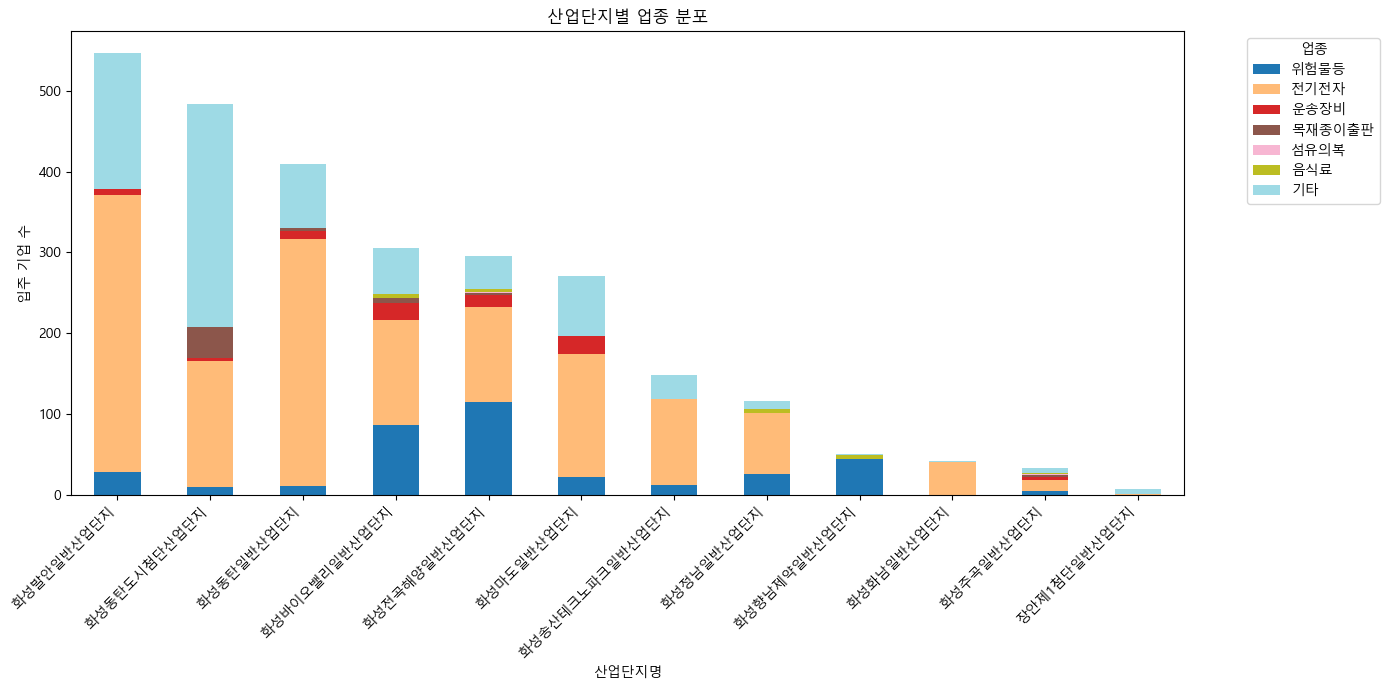

In [8]:
sorted_df = company_type_df.drop(columns=["합계"])
sorted_df["총합"] = sorted_df.sum(axis=1)
sorted_df = sorted_df.sort_values(by="총합", ascending=False).drop(columns=["총합"])

sorted_df.plot(kind="bar", stacked=True, figsize=(14, 7), colormap="tab20")
plt.title("산업단지별 업종 분포")
plt.xlabel("산업단지명")
plt.ylabel("입주 기업 수")
plt.xticks(rotation=45, ha="right")
plt.legend(title="업종", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

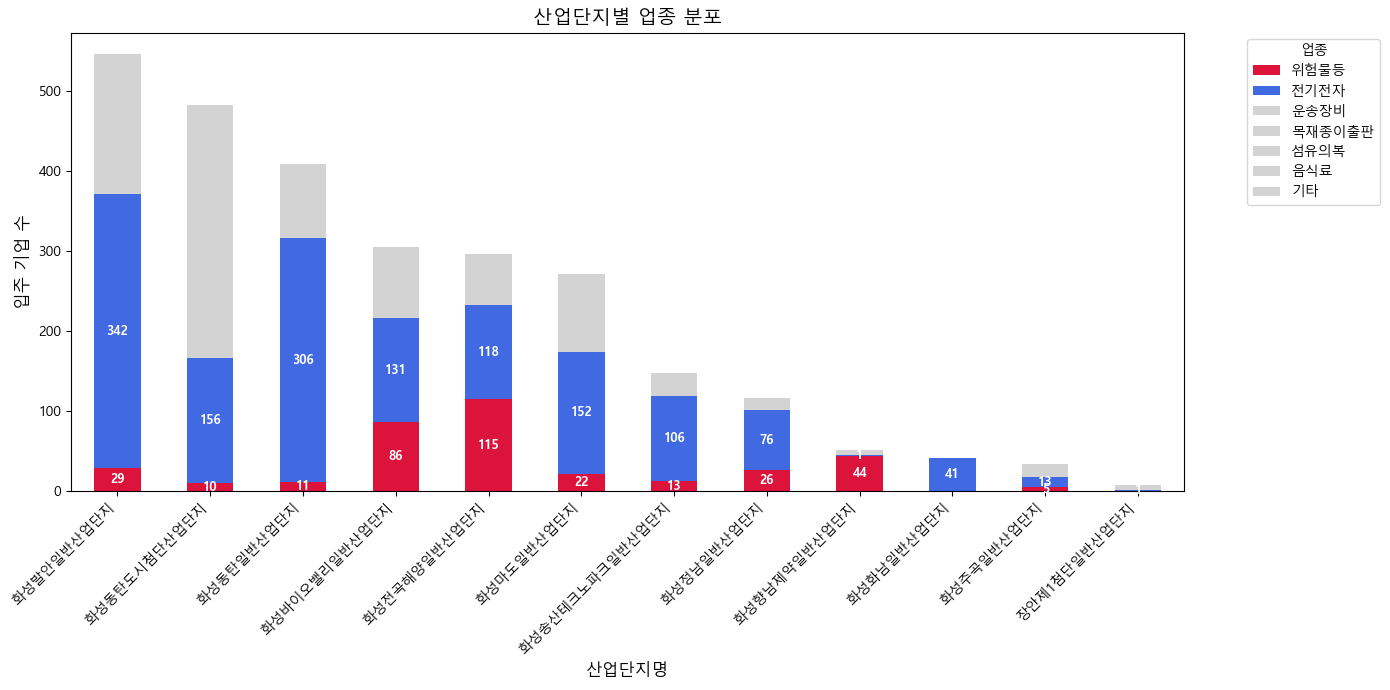

In [9]:
fig, ax = plt.subplots(figsize=(14, 7))

highlight_sectors = ["전기전자", "위험물등"]

color_map = {}
for col in sorted_df.columns:
    if col in highlight_sectors:
        color_map[col] = "crimson" if col == "위험물등" else "royalblue"
    else:
        color_map[col] = "lightgray"

bars = sorted_df.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    color=[color_map[col] for col in sorted_df.columns],
    ax=ax
)

for i, idx in enumerate(sorted_df.index):
    height_offset = 0
    for col in sorted_df.columns:
        height = sorted_df.loc[idx, col]
        if col in highlight_sectors and height > 0:
            ax.text(
                i,
                height_offset + height / 2,
                f"{int(height)}",
                ha='center',
                va='center',
                fontsize=9,
                color='white',
                fontweight='bold'
            )
        height_offset += height

plt.title("산업단지별 업종 분포", fontsize=14)
plt.xlabel("산업단지명", fontsize=12)
plt.ylabel("입주 기업 수", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="업종", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 위험 업종 포함 비율 계산

In [ ]:
def calculate_dangerous_ratio(row):
    dangerous_count = row["위험물등"] + row["전기전자"]
    total_count = row["합계"]
    ratio = dangerous_count / total_count
    return ratio

def danger_level(ratio):
    if ratio <= 0.2:
        return 1
    elif ratio <= 0.5:
        return 2
    else:
        return 3

company_type_df["위험 업종 비율"] = company_type_df.apply(calculate_dangerous_ratio, axis=1)
company_type_df["위험 업종 위험 수준"] = company_type_df["위험 업종 비율"].apply(danger_level)

company_type_df = company_type_df.sort_values(by=["위험 업종 비율"], ascending=False)

company_type_df

,위험물등,전기전자,운송장비,목재종이출판,섬유의복,음식료,기타,합계,위험 업종 비율,위험 업종 위험 수준
단지명,,,,,,,,,,
화성화남일반산업단지,0,41,0,0,0,0,1,42,0.976190,3
화성향남제약일반산업단지,44,1,0,0,0,4,2,51,0.882353,3
화성정남일반산업단지,26,76,0,0,0,4,10,116,0.879310,3
화성송산테크노파크일반산업단지,13,106,0,0,0,0,29,148,0.804054,3
화성전곡해양일반산업단지,115,118,14,3,1,4,41,296,0.787162,3
화성동탄일반산업단지,11,306,9,4,0,0,79,409,0.775061,3
화성바이오밸리일반산업단지,86,131,20,7,0,4,57,305,0.711475,3
화성발안일반산업단지,29,342,7,0,0,0,168,546,0.679487,3
화성마도일반산업단지,22,152,23,0,0,0,74,271,0.642066,3


# Metric 3) 소방서와의 거리
* 본 데이터의 소방서 위치는 '소방청'으로부터 다운로드 받았으며, 산업단지 위치는 '화성산업단지관리사업소'에서 다운로드 받았습니다.

In [10]:
company_address_df = pd.read_csv("../data/statistics/화성시_내_산업단지주소.csv", index_col = 0)
company_address_df

,주소
단지명,
화성동탄일반산업단지,경기 화성시 동탄산단6길 15-37
화성마도일반산업단지,경기 화성시 마도면 마도공단로5길 35
화성발안일반산업단지,경기 화성시 향남읍 발안공단로4길 21
화성전곡해양일반산업단지,경기 화성시 서신면 전곡산단로 141
화성정남일반산업단지,경기 화성시 정남면 정남산단3길 37
화성향남제약일반산업단지,경기 화성시 향남읍 제약공단2길 45
화성바이오밸리일반산업단지,경기 화성시 마도면 청원산단3길 140-32
화성주곡일반산업단지,경기 화성시 우정읍 버들로 899-87
화성화남일반산업단지,경기 화성시 서신면 화남공단로 48-11


In [11]:
firestation_address_df = pd.read_csv("../data/statistics/화성시_내_소방서_주소.csv", index_col = 0)
firestation_address_df

,주소
소방서명,
향남119안전센터,화성시 향남읍 향남로 399
태안119안전센터,화성시 병점중앙로 148 (진안동)
반송119안전센터,화성시 동탄반석로 188 (반송동)
봉담119안전센터,화성시 봉담읍 샘마을1길 9 (상리)
남양119안전센터,화성시 남양시장로 48 (남양읍)
정남119안전센터,화성시 정남면 정남동로 514 (고지리)
장안119안전센터,화성시 장안면 3.1만세로 119 (어은리)
목동119안전센터,화성시 동탄신리천로 359 (동탄4~7동)
팔탄119안전센터,화성시 팔탄면 구장리 557


## Kakao Map API을 활용해 위경도 변환

In [ ]:
def get_latlon_kakao(address, api_key=KAKAO_API_KEY):
    url = "https://dapi.kakao.com/v2/local/search/address.json"
    headers = {"Authorization": f"KakaoAK {api_key}"}
    params = {"query": address}
    try:
        response = requests.get(url, headers=headers, params=params)
        result = response.json()
        if result["documents"]:
            location = result["documents"][0]["address"]
            return float(location["y"]), float(location["x"])  # 위도, 경도
    except Exception as e:
        print(f"Error for address '{address}': {e}")
    return None, None

In [55]:
company_coords = company_address_df["주소"].apply(lambda x: get_latlon_kakao(x))
firestation_coords = firestation_address_df["주소"].apply(lambda x: get_latlon_kakao(x))

company_address_df[["위도", "경도"]] = pd.DataFrame(company_coords.tolist(), index=company_address_df.index)
firestation_address_df[["위도", "경도"]] = pd.DataFrame(firestation_coords.tolist(), index=firestation_address_df.index)

In [56]:
company_address_df

,주소,위도,경도
단지명,,,
화성동탄일반산업단지,경기 화성시 동탄산단6길 15-37,37.172092,127.088027
화성마도일반산업단지,경기 화성시 마도면 마도공단로5길 35,37.180876,126.790641
화성발안일반산업단지,경기 화성시 향남읍 발안공단로4길 21,37.083222,126.907938
화성전곡해양일반산업단지,경기 화성시 서신면 전곡산단로 141,37.188534,126.672069
화성정남일반산업단지,경기 화성시 정남면 정남산단3길 37,37.145270,127.026804
화성향남제약일반산업단지,경기 화성시 향남읍 제약공단2길 45,37.091714,126.905752
화성바이오밸리일반산업단지,경기 화성시 마도면 청원산단3길 140-32,37.170292,126.769581
화성주곡일반산업단지,경기 화성시 우정읍 버들로 899-87,37.118453,126.811920
화성화남일반산업단지,경기 화성시 서신면 화남공단로 48-11,37.159588,126.672474


In [57]:
firestation_address_df

,주소,위도,경도
소방서명,,,
향남119안전센터,화성시 향남읍 향남로 399,37.131011,126.920621
태안119안전센터,화성시 병점중앙로 148 (진안동),37.211179,127.038997
반송119안전센터,화성시 동탄반석로 188 (반송동),37.205462,127.072089
봉담119안전센터,화성시 봉담읍 샘마을1길 9 (상리),37.219349,126.949928
남양119안전센터,화성시 남양시장로 48 (남양읍),37.208697,126.814650
정남119안전센터,화성시 정남면 정남동로 514 (고지리),37.165097,127.002281
장안119안전센터,화성시 장안면 3.1만세로 119 (어은리),37.086348,126.826113
목동119안전센터,화성시 동탄신리천로 359 (동탄4~7동),37.183800,127.118212
팔탄119안전센터,화성시 팔탄면 구장리 557,37.160961,126.905185


## Kakao Map API를 이용해 산업단지 <-> 소방서 거리 측정

### 거리 측정 함수

In [ ]:
def get_road_distance_kakao(start_lon, start_lat, end_lon, end_lat, api_key):
    url = "https://apis-navi.kakaomobility.com/v1/directions"
    headers = {"Authorization": f"KakaoAK {api_key}"}
    params = {
        "origin": f"{start_lon},{start_lat}",
        "destination": f"{end_lon},{end_lat}",
        "priority": "RECOMMEND"
    }
    try:
        response = requests.get(url, headers=headers, params=params)
        data = response.json()
        if "routes" in data and len(data["routes"]) > 0:
            distance_m = data["routes"][0]["summary"]["distance"]
            return distance_m / 1000  # m → km
    except Exception as e:
        print(f"[ERROR] API failed: {e}")
    return None


### 가까운 소방서 계산 함수

In [ ]:
def find_nearest_firestation(company_df, firestation_df, api_key):
    results = []

    for company_name, company_row in company_df.iterrows():
        min_distance = float("inf")
        nearest_station = None

        for fire_name, fire_row in firestation_df.iterrows():
            road_dist = get_road_distance_kakao(
                start_lon=company_row["경도"], start_lat=company_row["위도"],
                end_lon=fire_row["경도"], end_lat=fire_row["위도"],
                api_key=api_key
            )

            if road_dist is not None and road_dist < min_distance:
                min_distance = road_dist
                nearest_station = fire_name

        results.append((company_name, nearest_station, round(min_distance, 2) if min_distance < float("inf") else None))

    result_df = pd.DataFrame(results, columns=["산업단지명", "가까운 소방서명", "소방 도로 거리 (km)"]).set_index("산업단지명")
    return result_df

result_df = find_nearest_firestation(company_address_df, firestation_address_df, KAKAO_API_KEY)

### 소방 거리 위험 수준 산정
* 소방청 발표에 따라, 소방서로부터 3km 이내는 '낮음', 3~5km는 '보통', 5km 이상은 '높음'으로 분류합니다.

In [ ]:
def classify_distance_risk(distance):
    if distance < 3:
        return 1
    elif distance < 5:
        return 2
    else:
        return 3

result_df["소방 거리 기준 위험 수준"] = result_df["소방 도로 거리 (km)"].apply(classify_distance_risk)

result_df

# Insight: 대부분의 산업단지가 소방서로부터 먼 거리에 위치해 있어, 화재 발생 시 신속한 대응이 어려울 수 있음.
#        : 특히, 소방서로부터 5km 이상 떨어진 산업단지가 많아, 추가적인 소방 인프라 구축이 필요함.

,가까운 소방서명,소방 도로 거리 (km),소방 거리 기준 위험 수준
산업단지명,,,
화성동탄일반산업단지,목동119안전센터,4.19,2
화성마도일반산업단지,남양119안전센터,5.36,3
화성발안일반산업단지,향남119안전센터,6.41,3
화성전곡해양일반산업단지,제부119지역대,6.91,3
화성정남일반산업단지,정남119안전센터,4.43,2
화성향남제약일반산업단지,향남119안전센터,5.00,3
화성바이오밸리일반산업단지,남양119안전센터,7.35,3
화성주곡일반산업단지,장안119안전센터,5.75,3
화성화남일반산업단지,제부119지역대,6.70,3


## 산업단지와 소방서와의 출동 시간 측정
* 출동 시간은 평일/주말에 따라서, 출/퇴근 시간에 따라서 상이할 수 있습니다.
* 이에 따라, T-MAP에서 직접 시간 설정 및 요일 설정을 통해 출동 시간을 기록 후 평균 내어 데이터를 생성하였습니다.

In [ ]:
time_df = pd.read_csv("../data/statistics/산업단지_소방서_소요시간.csv", index_col = 0)
time_df

,가까운 소방서,도로 거리(km),평균 출동 시간
산업단지명,,,
화성동탄일반산업단지,목동119안전센터,4.19,11.625000
화성마도일반산업단지,남양119안전센터,5.36,12.875000
화성발안일반산업단지,향남119안전센터,6.41,13.500000
화성전곡해양일반산업단지,제부119지역대,6.91,18.708330
화성정남일반산업단지,정남119안전센터,4.43,8.541667
화성향남제약일반산업단지,향남119안전센터,5.00,11.875000
화성바이오밸리일반산업단지,남양119안전센터,7.35,21.875000
화성주곡일반산업단지,장안119안전센터,6.11,14.000000
화성화남일반산업단지,제부119지역대,6.70,12.583330


### 출동 시간 위험 수준 측정 함수
* 소방청 발표에 따라, 소방서로부터 10분 이내는 '낮음', 15분 내는 '보통', 15분 이상은 '높음'으로 분류합니다.

In [ ]:
def classify_time_risk(time):
    if time < 10:
        return 1
    elif time < 15:
        return 2
    else:
        return 3

time_df["출동 시간 기준 위험 수준"] = time_df["평균 출동 시간"].apply(classify_distance_risk)

time_df

# Insight: 소방서로부터 안전한 거리 내에 존재하는 산업단지가 적으며, 평균 출동 시간도 긴 편이다.
#        : 이는 화재 발생 시 신속한 대응이 어려울 수 있음을 시사하며, 추가적인 대피소 설치나 소방 인프라 구축이 필요함.

,가까운 소방서,도로 거리(km),평균 출동 시간,출동 시간 기준 위험 수준
산업단지명,,,,
화성동탄일반산업단지,목동119안전센터,4.19,11.625000,2
화성마도일반산업단지,남양119안전센터,5.36,12.875000,2
화성발안일반산업단지,향남119안전센터,6.41,13.500000,2
화성전곡해양일반산업단지,제부119지역대,6.91,18.708330,3
화성정남일반산업단지,정남119안전센터,4.43,8.541667,1
화성향남제약일반산업단지,향남119안전센터,5.00,11.875000,2
화성바이오밸리일반산업단지,남양119안전센터,7.35,21.875000,3
화성주곡일반산업단지,장안119안전센터,6.11,14.000000,2
화성화남일반산업단지,제부119지역대,6.70,12.583330,2


## 추가 분석 (소방 거리 위험 수준 != 출동 시간 위험 수준)
* 실제 거리가 멀어도, 도로 상황에 따라 출동 시간은 빠를 수 있음.
* 따라서, 이 둘의 적절한 상호관계가 필요함을 확인함.

In [63]:
result_df['출동 시간 기준 위험 수준'] = time_df['출동 시간 기준 위험 수준']
result_df

,가까운 소방서명,소방 도로 거리 (km),소방 거리 기준 위험 수준,출동 시간 기준 위험 수준
산업단지명,,,,
화성동탄일반산업단지,목동119안전센터,4.19,2,2
화성마도일반산업단지,남양119안전센터,5.36,3,2
화성발안일반산업단지,향남119안전센터,6.41,3,2
화성전곡해양일반산업단지,제부119지역대,6.91,3,3
화성정남일반산업단지,정남119안전센터,4.43,2,1
화성향남제약일반산업단지,향남119안전센터,5.00,3,2
화성바이오밸리일반산업단지,남양119안전센터,7.35,3,3
화성주곡일반산업단지,장안119안전센터,5.75,3,2
화성화남일반산업단지,제부119지역대,6.70,3,2


## Metric 4) 도로 접근성 및 주변 인프라

## 도로 접근성 평가
* 선행 연구에 따라, 5km 이내에 큰 도로 (고속도로)가 존재시에 접근성이 좋은 것으로 분류한다.

### 도로 접근성 서치 함수

In [ ]:
headers = {
    "Authorization": f"KakaoAK {KAKAO_API_KEY}"
}

# 도로 접근성 평가 함수 (예: '고속도로입구' 키워드 기준)
def get_road_distance(lat, lon):
    url = "https://dapi.kakao.com/v2/local/search/keyword.json"
    params = {
        "query": "고속도로",
        "x": lon,
        "y": lat,
        "radius": 5000,
        "size": 1,
        "sort": "distance"
    }
    response = requests.get(url, headers=headers, params=params)
    data = response.json()
    if data["documents"]:
        return float(data["documents"][0]["distance"]) / 1000  # km
    else:
        return None  # 접근 가능한 고속도로가 없을 경우 None 반환

### 도로 접근성 평가

In [ ]:
def evaluate_environment(df):
    road_distances = []

    for idx, row in df.iterrows():
        lat = row["위도"]
        lon = row["경도"]
        road_distance = get_road_distance(lat, lon)

        # None인 경우를 대비하여 처리
        if road_distance is None:
            road_distance = -1  # 접근 불가를 의미하는 값으로 -1 사용

        road_distances.append(road_distance)

    df["고속도로 접근 거리(km)"] = road_distances
    return df

company_address_df = evaluate_environment(company_address_df)

result_df = result_df.merge(company_address_df[["고속도로 접근 거리(km)"]], 
                            left_index=True, right_index=True)

result_df

,가까운 소방서명,소방 도로 거리 (km),소방 거리 기준 위험 수준,출동 시간 기준 위험 수준,고속도로 접근 거리(km)
화성동탄일반산업단지,목동119안전센터,4.19,2,2,3.339
화성마도일반산업단지,남양119안전센터,5.36,3,2,3.176
화성발안일반산업단지,향남119안전센터,6.41,3,2,7.664
화성전곡해양일반산업단지,제부119지역대,6.91,3,3,7.690
화성정남일반산업단지,정남119안전센터,4.43,2,1,2.121
화성향남제약일반산업단지,향남119안전센터,5.00,3,2,7.886
화성바이오밸리일반산업단지,남양119안전센터,7.35,3,3,3.432
화성주곡일반산업단지,장안119안전센터,5.75,3,2,1.139
화성화남일반산업단지,제부119지역대,6.70,3,2,9.172
화성송산테크노파크일반산업단지,송산119지역대,5.39,3,2,5.271


## 주변 인프라 평가
* 선행 연구에 따라, 산림형 공간이 사고 지점으로부터 1km 이내에 존재 시 위험도가 높은 것으로 분류한다.

### 주변 인프라 서치 함수

In [ ]:
def search_places(query, lat, lon, radius=1000):
    url = "https://dapi.kakao.com/v2/local/search/keyword.json"
    params = {
        "query": query,
        "x": lon,
        "y": lat,
        "radius": radius,
        "size": 15,
        "sort": "distance"
    }
    response = requests.get(url, headers=headers, params=params)
    if response.status_code == 200:
        return response.json().get("documents", [])
    else:
        return []

forest_keywords = ["산", "자연", "생태", "숲", "수목"]
def is_forest_park(name):
    return any(keyword in name for keyword in forest_keywords)

### 주변 인프라 평가 함수

In [ ]:
def analyze_surroundings(df):
    park_counts = []
    sensitive_counts = []
    river_counts = []

    for idx, row in df.iterrows():
        lat, lon = row["위도"], row["경도"]

        # 1. 산림형 공원 개수
        parks = search_places("공원", lat, lon)
        forest_parks = [p for p in parks if is_forest_park(p["place_name"])]
        park_coords = {(p["x"], p["y"]) for p in forest_parks}
        park_counts.append(len(park_coords))

        # 2. 민감시설 개수
        sensitive_keywords = ["어린이집", "유치원", "초등학교", "병원", "노인요양"]
        sensitive_places = []
        for keyword in sensitive_keywords:
            sensitive_places += search_places(keyword, lat, lon)
        sensitive_coords = {(p["x"], p["y"]) for p in sensitive_places}
        sensitive_counts.append(len(sensitive_coords))

        # 3. 수변 요소 개수
        river_keywords = ["하천", "강", "바다"]
        river_places = []
        for keyword in river_keywords:
            river_places += search_places(keyword, lat, lon)
        river_coords = {(p["x"], p["y"]) for p in river_places}
        river_counts.append(len(river_coords))

    df["산림형 공원 수"] = park_counts
    df["민감시설 수"] = sensitive_counts
    df["수변 요소 수"] = river_counts
    return df

company_address_df = analyze_surroundings(company_address_df)

result_df = result_df.merge(
    company_address_df[["산림형 공원 수", "민감시설 수", "수변 요소 수"]],
    left_index=True, right_index=True
)

result_df

,가까운 소방서명,소방 도로 거리 (km),소방 거리 기준 위험 수준,출동 시간 기준 위험 수준,고속도로 접근 거리(km),산림형 공원 수,민감시설 수,수변 요소 수
화성동탄일반산업단지,목동119안전센터,4.19,2,2,3.339,0,3,1
화성마도일반산업단지,남양119안전센터,5.36,3,2,3.176,0,0,0
화성발안일반산업단지,향남119안전센터,6.41,3,2,7.664,0,2,1
화성전곡해양일반산업단지,제부119지역대,6.91,3,3,7.690,0,0,0
화성정남일반산업단지,정남119안전센터,4.43,2,1,2.121,0,1,0
화성향남제약일반산업단지,향남119안전센터,5.00,3,2,7.886,0,4,2
화성바이오밸리일반산업단지,남양119안전센터,7.35,3,3,3.432,0,0,0
화성주곡일반산업단지,장안119안전센터,5.75,3,2,1.139,0,0,0
화성화남일반산업단지,제부119지역대,6.70,3,2,9.172,0,0,2
화성송산테크노파크일반산업단지,송산119지역대,5.39,3,2,5.271,0,0,0


# 결과 병합
* 산업단지별 혼합밀집도 + 소방 거리 위험 수준 + 출동 거리 위험 수준 + 주변 인프라 + 도로 접근성

In [66]:
company_df

,회사수,면적,직원수,직원밀집도,기업밀집도,혼합밀집도
단지명,,,,,,
화성발안일반산업단지,424,1825,8884,4.867945,0.232329,3.477260
화성동탄일반산업단지,328,1974,14237,7.212259,0.166160,5.098430
화성동탄도시첨단산업단지,251,149,3935,26.409396,1.684564,18.991946
화성전곡해양일반산업단지,233,1617,4051,2.505257,0.144094,1.796908
화성바이오밸리일반산업단지,227,1740,4787,2.751149,0.130460,1.964943
화성마도일반산업단지,173,929,4029,4.336921,0.186222,3.091712
화성송산테크노파크일반산업단지,99,529,1513,2.860113,0.187146,2.058223
화성정남일반산업단지,95,569,2956,5.195079,0.166960,3.686643
화성향남제약일반산업단지,48,648,4409,6.804012,0.074074,4.785031


In [67]:
selected_company_df = company_df[["회사수", "면적", "혼합밀집도"]]

merged_df = pd.concat([selected_company_df, result_df], axis=1)

final_df = merged_df.sort_values(by="회사수", ascending=False)

final_df

,회사수,면적,혼합밀집도,가까운 소방서명,소방 도로 거리 (km),소방 거리 기준 위험 수준,출동 시간 기준 위험 수준,고속도로 접근 거리(km),산림형 공원 수,민감시설 수,수변 요소 수
화성발안일반산업단지,424,1825,3.477260,향남119안전센터,6.41,3,2,7.664,0,2,1
화성동탄일반산업단지,328,1974,5.098430,목동119안전센터,4.19,2,2,3.339,0,3,1
화성동탄도시첨단산업단지,251,149,18.991946,반송119안전센터,2.61,1,1,1.380,0,17,5
화성전곡해양일반산업단지,233,1617,1.796908,제부119지역대,6.91,3,3,7.690,0,0,0
화성바이오밸리일반산업단지,227,1740,1.964943,남양119안전센터,7.35,3,3,3.432,0,0,0
화성마도일반산업단지,173,929,3.091712,남양119안전센터,5.36,3,2,3.176,0,0,0
화성송산테크노파크일반산업단지,99,529,2.058223,송산119지역대,5.39,3,2,5.271,0,0,0
화성정남일반산업단지,95,569,3.686643,정남119안전센터,4.43,2,1,2.121,0,1,0
화성향남제약일반산업단지,48,648,4.785031,향남119안전센터,5.00,3,2,7.886,0,4,2
화성화남일반산업단지,36,151,2.199338,제부119지역대,6.70,3,2,9.172,0,0,2


In [68]:
final_df = final_df[['혼합밀집도', '소방 거리 기준 위험 수준', '출동 시간 기준 위험 수준', '고속도로 접근 거리(km)', '산림형 공원 수', '민감시설 수', '수변 요소 수']]
final_df['위험 업종 위험 수준'] = company_type_df['위험 업종 위험 수준']
final_df

/tmp/ipykernel_356620/150681722.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['위험 업종 위험 수준'] = company_type_df['위험 업종 위험 수준']


,혼합밀집도,소방 거리 기준 위험 수준,출동 시간 기준 위험 수준,고속도로 접근 거리(km),산림형 공원 수,민감시설 수,수변 요소 수,위험 업종 위험 수준
화성발안일반산업단지,3.477260,3,2,7.664,0,2,1,3
화성동탄일반산업단지,5.098430,2,2,3.339,0,3,1,3
화성동탄도시첨단산업단지,18.991946,1,1,1.380,0,17,5,2
화성전곡해양일반산업단지,1.796908,3,3,7.690,0,0,0,3
화성바이오밸리일반산업단지,1.964943,3,3,3.432,0,0,0,3
화성마도일반산업단지,3.091712,3,2,3.176,0,0,0,3
화성송산테크노파크일반산업단지,2.058223,3,2,5.271,0,0,0,3
화성정남일반산업단지,3.686643,2,1,2.121,0,1,0,3
화성향남제약일반산업단지,4.785031,3,2,7.886,0,4,2,3
화성화남일반산업단지,2.199338,3,2,9.172,0,0,2,3


# 위험도 측정

## 위험도 측정 함수
* weight는 인명 피해를 고려하여 중요도에 따라 분류

In [ ]:
def calculate_risk(row):
    weights = {
        "혼합밀집도": 0.10,
        "소방 거리 기준 위험 수준": 0.15,
        "출동 시간 기준 위험 수준": 0.25,
        "고속도로 접근 거리(km)": 0.10,
        "산림형 공원 수": 0.05,
        "민감시설 수": 0.05,
        "수변 요소 수": 0.05,
        "위험 업종 위험 수준": 0.25
    }

    risk_score = (
        weights["혼합밀집도"] * row["혼합밀집도"] +
        weights["소방 거리 기준 위험 수준"] * row["소방 거리 기준 위험 수준"] +
        weights["출동 시간 기준 위험 수준"] * row["출동 시간 기준 위험 수준"] +
        weights["고속도로 접근 거리(km)"] * row["고속도로 접근 거리(km)"] +
        weights["산림형 공원 수"] * row["산림형 공원 수"] +
        weights["민감시설 수"] * row["민감시설 수"] +
        weights["수변 요소 수"] * row["수변 요소 수"] +
        weights["위험 업종 위험 수준"] * row["위험 업종 위험 수준"]
    )
    return risk_score

def risk_level(score):
    if score <= 1.5:
        return "1단계 (안전)"
    elif score <= 2.5:
        return "2단계 (주의)"
    else:
        return "3단계 (위험)"

In [ ]:
final_df["위험도"] = final_df.apply(calculate_risk, axis=1)
final_df["위험 수준"] = final_df["위험도"].apply(risk_level)

sorted_final_df = final_df.sort_values(by=["위험도"], ascending=False)

sorted_final_df[['위험도', '위험 수준']]

/tmp/ipykernel_356620/2950052954.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df["위험도"] = final_df.apply(calculate_risk, axis=1)
/tmp/ipykernel_356620/2950052954.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df["위험 수준"] = final_df["위험도"].apply(risk_level)


,위험도,위험 수준
화성동탄도시첨단산업단지,4.037195,3단계 (위험)
화성향남제약일반산업단지,3.267103,3단계 (위험)
화성발안일반산업단지,2.964126,3단계 (위험)
화성화남일반산업단지,2.937134,3단계 (위험)
화성전곡해양일반산업단지,2.898691,3단계 (위험)
화성동탄일반산업단지,2.593743,3단계 (위험)
화성바이오밸리일반산업단지,2.489694,2단계 (주의)
화성송산테크노파크일반산업단지,2.432922,2단계 (주의)
화성마도일반산업단지,2.326771,2단계 (주의)
화성주곡일반산업단지,1.997900,2단계 (주의)
